In [5]:
import pandas as pd
import numpy as np
import sklearn.metrics.pairwise as dist
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Modélisation par la méthode K-Means. Le but est de regrouper les films en clusters, chaque cluster contenant des films similaires. Nous allons nous baser sur les genome tags afin de regrouper les films

In [2]:
genome_scores = pd.read_csv('genome_scores_cleaned.csv')

genome_scores.head()

,movieId,tagId,relevance
0,1,11,0.57700
1,1,19,0.67050
2,1,29,0.89200
3,1,30,0.67625
4,1,61,0.54475


In [3]:
# nous faisons pivoter le dataframe afin d'avoir les tagId en colonnes, relevance en valeur, et donc une ligne par film
gs_pivot = genome_scores.pivot(index='movieId', columns='tagId', values='relevance')
# lorsqu'il n'y a pas de tag pour un film, on remplace par 0 (pas de pertinence). La valeur 0 est préférable à la relevance <0,5 car ça nous évite de prendre en compte une relation qui n'existe pas
gs_pivot = gs_pivot.fillna(0)
display(gs_pivot.shape)
gs_pivot.head()

(10381, 1127)

tagId,1,2,3,4,5,6,7,8,9,10,...,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128
movieId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Les valeurs sont toutes comprises entre 0 et 1, il n'y a pas besoin de normalisation. Cependant, il y a 1127 colonnes. Nous allons réduire ce nombre avec la méthode PCA (Principal Component Analysis / analyse en Composantes Principales). Technique de réduction de dimensionnalité dont le but est de résumer un grand nombre de variables en un plus petit nombre, tout en conservant le maximum d'information possible.

In [6]:
# on va réduire la dimensionnalité du dataframe gs_pivot avec PCA pour ne garder que les composantes principales qui expliquent 90% de la variance
pca = PCA(n_components=0.90, random_state=42)
gs_reduced = pca.fit_transform(gs_pivot)

# nombre de composnantes principales conservées et variance expliquée
print(f"Nombre de composantes principales conservées : {pca.n_components_}")
print(f"Variance expliquée : {np.sum(pca.explained_variance_ratio_)}")

Nombre de composantes principales conservées : 440
Variance expliquée : 0.9003727336304894


440 variables, ça reste élevé pour le K-Mean, les distances euclidiennes seront moins discriminantes. Nous allons afficher la courbe de variance cumulée afin d'identifier un seuil raisonable

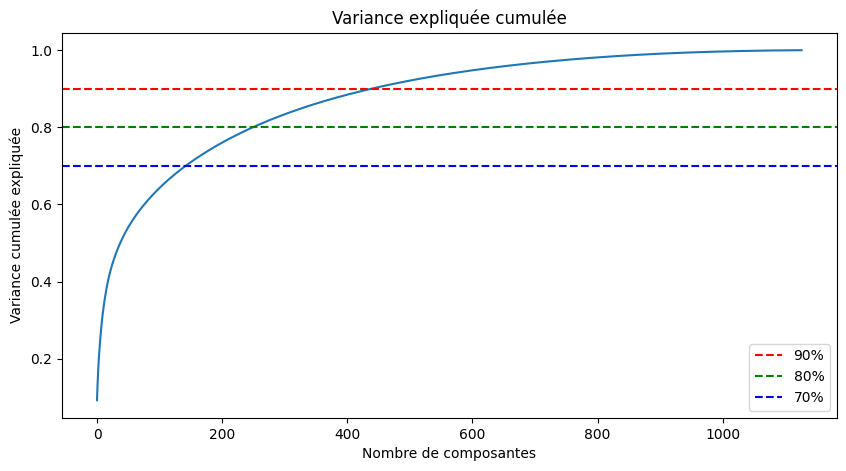

In [7]:
pca_full = PCA(random_state=42)
pca_full.fit(gs_pivot)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée expliquée')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.axhline(y=0.80, color='g', linestyle='--', label='80%')
plt.axhline(y=0.70, color='b', linestyle='--', label='70%')
plt.legend()
plt.title('Variance expliquée cumulée')
plt.show()

la courbe est très progressive, pas de coude franc. 150 composants semble être un bon compromis, avec une variance proche de 70%

In [8]:
pca = PCA(n_components=150, random_state=42)
gs_reduced = pca.fit_transform(gs_pivot)

print(f"Composantes conservées : {pca.n_components_}")
print(f"Variance expliquée : {np.sum(pca.explained_variance_ratio_):.2%}")

Composantes conservées : 150
Variance expliquée : 70.60%


nous partons donc sur 150 composantes principales pour représenter les films dans l'espace des tags, ce qui permet de réduire la dimensionnalité tout en conservant 70,60% de l'information pertinente.  

In [9]:
gs_reduced.shape

(10381, 150)

La dimensionnalité des variables étant réduite, nous pouvons passer à la modélisation K-means. Nous allons utiliser la méthode du coude (Elbow) pour déterminer le nombre de clusters k

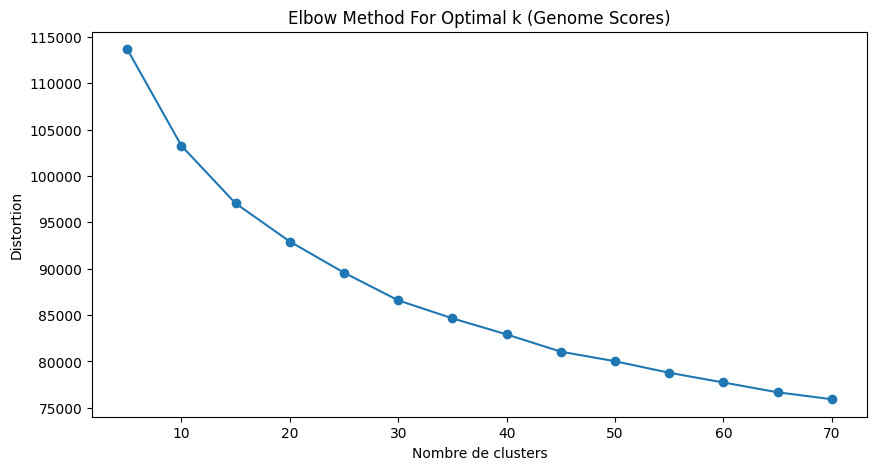

In [10]:
distortions = []
K_range = range(5, 71, 5)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(gs_reduced)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, distortions, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method For Optimal k (Genome Scores)')
plt.show()

Pas de coude franc, la courbe continue de décroître. On passe à la méthode de la silhouette pour déterminer le nombre de clusters optimal k

Meilleur k : 5 (silhouette = 0.1132)


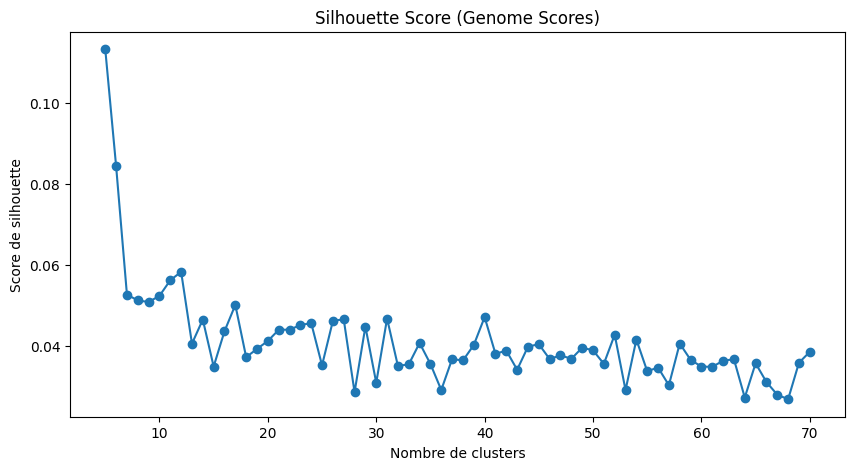

In [11]:
silhouette_scores = []
K_range = range(5, 71)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(gs_reduced)
    silhouette_scores.append(silhouette_score(gs_reduced, labels))

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"Meilleur k : {best_k} (silhouette = {max(silhouette_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Silhouette Score (Genome Scores)')
plt.show()

Les scores sont très bas (max 0,1132) et la courbe descend dès k=5, ce qui fait très peu de clusters. Les genome scores ne semblent pas se prêter au K-Means. Les clusters ne sont pas bien séparés. Même avec PCA à 150 composantes, l'information reste trop diffuse.

Mettons en place le modèle avec k=5

In [12]:
kmeans_genome = KMeans(n_clusters=5, random_state=42, n_init=10)
gs_pivot['cluster_genome'] = kmeans_genome.fit_predict(gs_reduced)

print(gs_pivot['cluster_genome'].value_counts())

cluster_genome
1    6028
0    1304
2    1148
4    1140
3     761
Name: count, dtype: int64


Ce qui confirme notre appéciation précédente avec une silhouette à 0,11. Le cluster 0 contient 6032 films sur 10380, soit 58% du total. Les clusters sont très déséquilibrés. K-Means crée un méga-cluster fourre-tout et 4 petits clusters périphériques